In [ ]:
!pip install -q gradio segmentation_models_pytorch pillow scipy matplotlib albumentations opencv-python
!rm -rf /content/sam2
!git clone https://github.com/facebookresearch/sam2.git /content/sam2
%cd /content/sam2
!SAM2_BUILD_CUDA=0 pip install -q -e ".[notebooks]"
!mkdir -p checkpoints
!wget -q -O /content/sam2/checkpoints/sam2.1_hiera_small.pt https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.1 MB/s eta 0:00:00
Cloning into '/content/sam2'...
remote: Enumerating objects: 1096, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 1096 (delta 1), reused 0 (delta 0), pack-reused 1094 (from 2)
Receiving objects: 100% (1096/1096), 134.84 MiB | 16.16 MiB/s, done.
Resolving deltas: 100% (376/376), done.
/content/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 95.3 MB/s e

In [ ]:
import os
os.chdir("/content")
print(os.getcwd())

/content


In [ ]:
import os, json, cv2
import numpy as np
import torch
import torch.nn as nn
import gradio as gr
import matplotlib.pyplot as plt

from glob import glob
from PIL import Image
from scipy import ndimage
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from google.colab import drive
drive.mount('/content/drive')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATASET_DIR = "/content/drive/MyDrive/goruntulercrop"
TRAIN_IMAGE_DIR = f"{DATASET_DIR}/train/images"
TRAIN_MASK_DIR  = f"{DATASET_DIR}/train/masks"
TEST_IMAGE_DIR  = f"{DATASET_DIR}/test/images"
TEST_MASK_DIR   = f"{DATASET_DIR}/test/masks"

UNET_WEIGHT_PATH = "/content/drive/MyDrive/pnomotoraks_unet_goruntulercrop.pth"

IMAGE_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 20

print("Cihaz:", DEVICE)
print("Veri yolu:", DATASET_DIR)

Mounted at /content/drive
Cihaz: cuda
Veri yolu: /content/drive/MyDrive/goruntulercrop


In [ ]:
class PnomotoraksDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.transform = transform
        exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp"]
        image_paths = []

        for ext in exts:
            image_paths.extend(glob(os.path.join(image_dir, ext)))

        image_paths = sorted(image_paths)
        self.samples = []

        for img_path in image_paths:
            name = os.path.splitext(os.path.basename(img_path))[0]

            possible_masks = [
                os.path.join(mask_dir, name + ".png"),
                os.path.join(mask_dir, name + ".jpg"),
                os.path.join(mask_dir, name + ".jpeg"),
                os.path.join(mask_dir, name + ".bmp"),
            ]

            mask_path = None
            for p in possible_masks:
                if os.path.exists(p):
                    mask_path = p
                    break

            if mask_path:
                self.samples.append((img_path, mask_path))

        print(f"{image_dir} eşleşen örnek sayısı:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask = aug["mask"].unsqueeze(0)

        return image, mask

In [ ]:
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.3),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_dataset = PnomotoraksDataset(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, train_transform)
test_dataset  = PnomotoraksDataset(TEST_IMAGE_DIR, TEST_MASK_DIR, test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

/content/drive/MyDrive/goruntulercrop/train/images eşleşen örnek sayısı: 3858
/content/drive/MyDrive/goruntulercrop/test/images eşleşen örnek sayısı: 1071


In [ ]:
unet_model = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(DEVICE)

dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * dice_loss(pred, target) + 0.5 * bce_loss(pred, target)

optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

In [ ]:
def calculate_metrics_batch(preds, masks, eps=1e-6):
    preds = preds.detach().cpu().numpy().astype(np.uint8)
    masks = masks.detach().cpu().numpy().astype(np.uint8)

    dices, ious, accs = [], [], []

    for i in range(preds.shape[0]):
        pred = preds[i, 0].flatten()
        true = masks[i, 0].flatten()

        tp = np.sum((pred == 1) & (true == 1))
        tn = np.sum((pred == 0) & (true == 0))
        fp = np.sum((pred == 1) & (true == 0))
        fn = np.sum((pred == 0) & (true == 1))

        dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
        iou = (tp + eps) / (tp + fp + fn + eps)
        acc = (tp + tn + eps) / (tp + tn + fp + fn + eps)

        dices.append(dice)
        ious.append(iou)
        accs.append(acc)

    return np.mean(dices), np.mean(ious), np.mean(accs)

In [ ]:
import torch

def train_unet_with_graphs(num_epochs=50):
    history = {
        "train_loss": [],
        "val_loss": [],

        "train_dice": [],
        "val_dice": [],

        "train_iou": [],
        "val_iou": [],

        "train_accuracy": [],
        "val_accuracy": []
    }

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    print("Eğitim başlıyor...")
    print(f"Toplam Epoch: {num_epochs}")

    for epoch in range(num_epochs):

        # =========================
        # TRAIN
        # =========================
        unet_model.train()

        train_loss = 0.0
        train_dice = 0.0
        train_iou = 0.0
        train_acc = 0.0
        train_batch_count = 0

        for images, masks in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()

            outputs = unet_model(images)
            loss = loss_fn(outputs, masks)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            dice, iou, acc = calculate_metrics_batch(preds, masks)

            train_dice += dice
            train_iou += iou
            train_acc += acc
            train_batch_count += 1

        avg_train_loss = train_loss / max(len(train_loader), 1)
        avg_train_dice = train_dice / max(train_batch_count, 1)
        avg_train_iou = train_iou / max(train_batch_count, 1)
        avg_train_acc = train_acc / max(train_batch_count, 1)

        # =========================
        # VALIDATION
        # =========================
        unet_model.eval()

        val_loss = 0.0
        val_dice = 0.0
        val_iou = 0.0
        val_acc = 0.0
        val_batch_count = 0

        with torch.no_grad():
            for images, masks in test_loader:
                images = images.to(DEVICE, non_blocking=True)
                masks = masks.to(DEVICE, non_blocking=True)

                outputs = unet_model(images)
                loss = loss_fn(outputs, masks)

                val_loss += loss.item()

                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).float()

                dice, iou, acc = calculate_metrics_batch(preds, masks)

                val_dice += dice
                val_iou += iou
                val_acc += acc
                val_batch_count += 1

        avg_val_loss = val_loss / max(len(test_loader), 1)
        avg_val_dice = val_dice / max(val_batch_count, 1)
        avg_val_iou = val_iou / max(val_batch_count, 1)
        avg_val_acc = val_acc / max(val_batch_count, 1)

        scheduler.step(avg_val_loss)

        # =========================
        # HISTORY
        # =========================
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)

        history["train_dice"].append(avg_train_dice)
        history["val_dice"].append(avg_val_dice)

        history["train_iou"].append(avg_train_iou)
        history["val_iou"].append(avg_val_iou)

        history["train_accuracy"].append(avg_train_acc)
        history["val_accuracy"].append(avg_val_acc)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"LR: {current_lr:.6f} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Train Dice: {avg_train_dice:.4f} | "
            f"Val Dice: {avg_val_dice:.4f} | "
            f"Train IoU: {avg_train_iou:.4f} | "
            f"Val IoU: {avg_val_iou:.4f} | "
            f"Train Acc: {avg_train_acc:.4f} | "
            f"Val Acc: {avg_val_acc:.4f}"
        )

    torch.save(unet_model.state_dict(), UNET_WEIGHT_PATH)
    print("50 epoch tamamlandı. Model kaydedildi:", UNET_WEIGHT_PATH)

    return history


history = train_unet_with_graphs(num_epochs=50)

Eğitim başlıyor...
Toplam Epoch: 50
Epoch [1/50] | LR: 0.000100 | Train Loss: 0.1960 | Val Loss: 0.1381 | Train Dice: 0.8158 | Val Dice: 0.8982 | Train IoU: 0.7436 | Val IoU: 0.8458 | Train Acc: 0.9503 | Val Acc: 0.9693
Epoch [2/50] | LR: 0.000100 | Train Loss: 0.0957 | Val Loss: 0.1172 | Train Dice: 0.8971 | Val Dice: 0.9059 | Train IoU: 0.8440 | Val IoU: 0.8576 | Train Acc: 0.9716 | Val Acc: 0.9716
Epoch [3/50] | LR: 0.000100 | Train Loss: 0.0783 | Val Loss: 0.0866 | Train Dice: 0.9118 | Val Dice: 0.9280 | Train IoU: 0.8628 | Val IoU: 0.8852 | Train Acc: 0.9756 | Val Acc: 0.9771
Epoch [4/50] | LR: 0.000100 | Train Loss: 0.0780 | Val Loss: 0.0903 | Train Dice: 0.9123 | Val Dice: 0.9253 | Train IoU: 0.8637 | Val IoU: 0.8815 | Train Acc: 0.9754 | Val Acc: 0.9766
Epoch [5/50] | LR: 0.000100 | Train Loss: 0.0680 | Val Loss: 0.0820 | Train Dice: 0.9224 | Val Dice: 0.9302 | Train IoU: 0.8758 | Val IoU: 0.8876 | Train Acc: 0.9776 | Val Acc: 0.9775
Epoch [6/50] | LR: 0.000100 | Train Loss: 0.

In [ ]:
import pickle

with open("/content/drive/MyDrive/history.pkl", "wb") as f:
    pickle.dump(history, f)

print("history kaydedildi")

history kaydedildi


In [ ]:
import torch
import segmentation_models_pytorch as smp
from google.colab import drive

drive.mount('/content/drive')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

UNET_WEIGHT_PATH = "/content/drive/MyDrive/pnomotoraks_unet_goruntulercrop.pth"

unet_model = smp.Unet(
    encoder_name="mobilenet_v2",   # eğitimde hangi encoder kullandıysan aynısı olmalı
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
).to(DEVICE)

unet_model.load_state_dict(
    torch.load(UNET_WEIGHT_PATH, map_location=DEVICE)
)

unet_model.eval()

print("Kayıtlı U-Net modeli başarıyla yüklendi. Eğitim atlandı.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kayıtlı U-Net modeli başarıyla yüklendi. Eğitim atlandı.


In [ ]:
import pickle

with open("/content/drive/MyDrive/history.pkl", "rb") as f:
    history = pickle.load(f)

print("history geri yüklendi")

history geri yüklendi


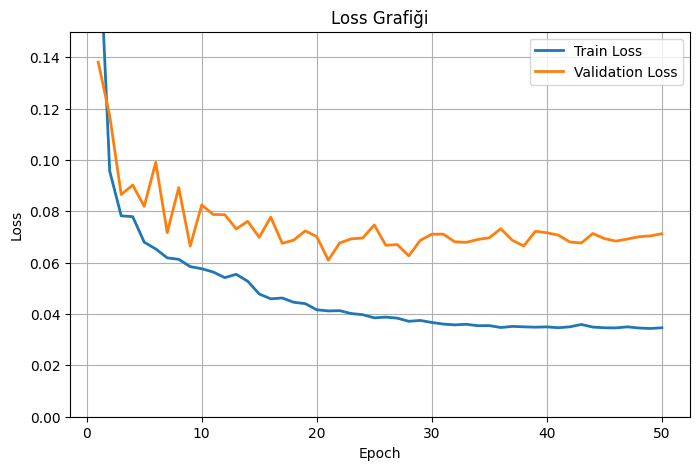

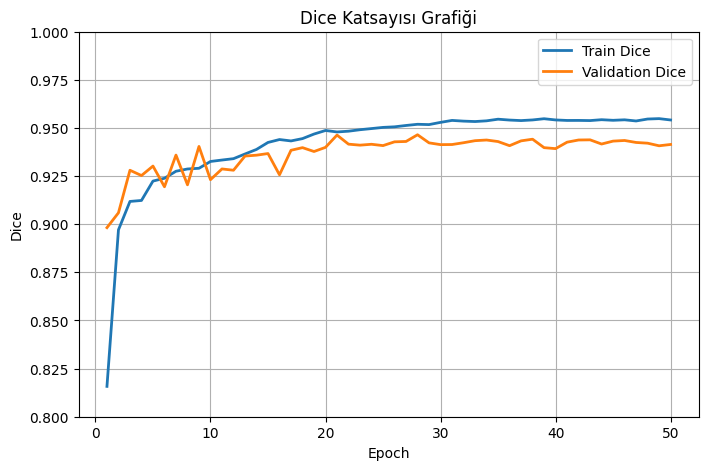

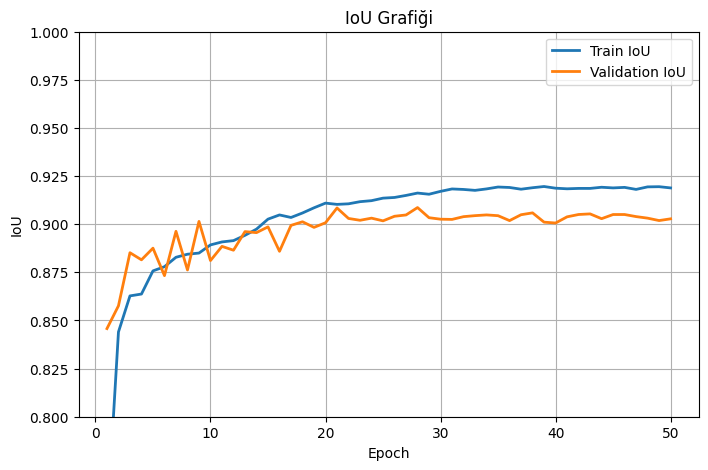

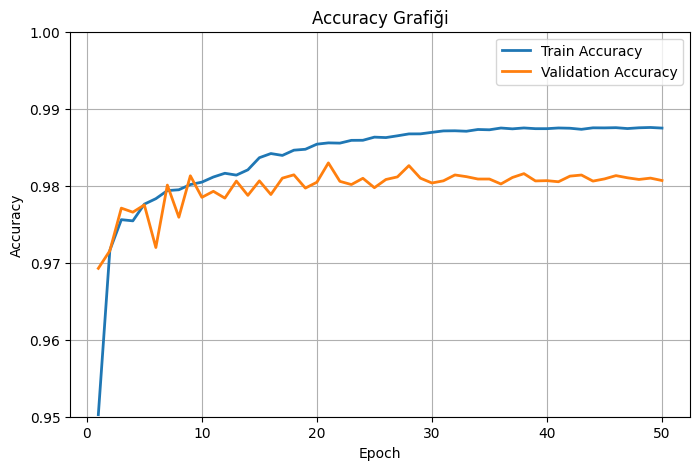

KeyError: 'lr'

<Figure size 800x500 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

# =========================
# 1. LOSS GRAFİĞİ
# =========================
plt.figure(figsize=(8,5))
plt.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(epochs, history["val_loss"], label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Grafiği")
plt.ylim(0.00, 0.15)   # Sabit eksen
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 2. DICE GRAFİĞİ
# =========================
plt.figure(figsize=(8,5))
plt.plot(epochs, history["train_dice"], label="Train Dice", linewidth=2)
plt.plot(epochs, history["val_dice"], label="Validation Dice", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Dice Katsayısı Grafiği")
plt.ylim(0.80, 1.00)   # Sabit eksen
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 3. IoU GRAFİĞİ
# =========================
plt.figure(figsize=(8,5))
plt.plot(epochs, history["train_iou"], label="Train IoU", linewidth=2)
plt.plot(epochs, history["val_iou"], label="Validation IoU", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("IoU Grafiği")
plt.ylim(0.80, 1.00)   # Sabit eksen
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 4. ACCURACY GRAFİĞİ
# =========================
plt.figure(figsize=(8,5))
plt.plot(epochs, history["train_accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Grafiği")
plt.ylim(0.95, 1.00)   # Sabit eksen
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 5. LEARNING RATE GRAFİĞİ
# =========================
plt.figure(figsize=(8,5))
plt.plot(epochs, history["lr"], label="Learning Rate", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate (LR) Grafiği")
plt.legend()
plt.grid(True)
plt.show()

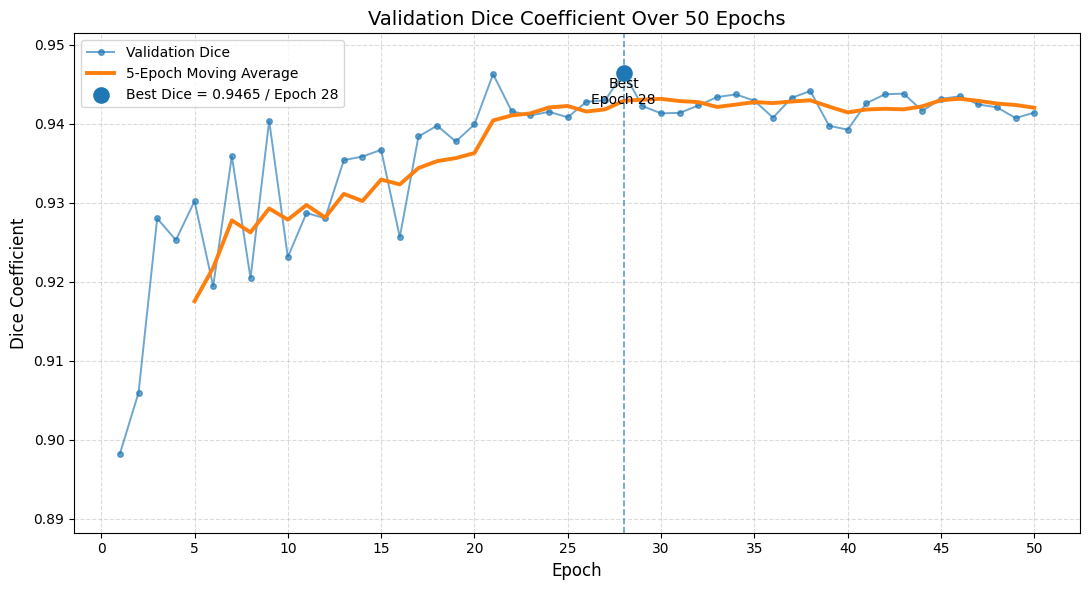

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dice_values = history["val_dice"]
epochs = np.arange(1, len(dice_values) + 1)

# 5 epoch hareketli ortalama
window = 5
smooth_dice = np.convolve(
    dice_values,
    np.ones(window) / window,
    mode="valid"
)
smooth_epochs = epochs[window-1:]

best_epoch = int(np.argmax(dice_values)) + 1
best_dice = max(dice_values)

plt.figure(figsize=(11, 6))

plt.plot(
    epochs,
    dice_values,
    marker="o",
    markersize=4,
    linewidth=1.4,
    alpha=0.65,
    label="Validation Dice"
)

plt.plot(
    smooth_epochs,
    smooth_dice,
    linewidth=2.8,
    label="5-Epoch Moving Average"
)

plt.scatter(
    best_epoch,
    best_dice,
    s=120,
    zorder=5,
    label=f"Best Dice = {best_dice:.4f} / Epoch {best_epoch}"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7
)

plt.text(
    best_epoch,
    best_dice - 0.004,
    f"Best\nEpoch {best_epoch}",
    ha="center",
    fontsize=10
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Dice Coefficient", fontsize=12)
plt.title("Validation Dice Coefficient Over 50 Epochs", fontsize=14)

plt.xticks(np.arange(0, len(epochs)+1, 5))
plt.ylim(min(dice_values) - 0.01, max(dice_values) + 0.005)

plt.grid(True, linestyle="--", alpha=0.45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Kullanılan cihaz:", DEVICE)

In [ ]:
import torch
import sys

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Cihaz:", DEVICE)

sys.path.insert(0, "/content/sam2")

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

SAM2_CHECKPOINT = "/content/sam2/checkpoints/sam2.1_hiera_small.pt"
SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_s.yaml"

sam2_model = build_sam2(
    config_file=SAM2_CONFIG,
    ckpt_path=SAM2_CHECKPOINT,
    device=DEVICE
)

sam2_predictor = SAM2ImagePredictor(sam2_model)

print("SAM2 hazır.")

Cihaz: cuda
SAM2 hazır.


In [ ]:
def clean_mask(mask, min_area=80):
    mask = (mask > 0).astype(np.uint8)
    labeled, num = ndimage.label(mask)
    out = np.zeros_like(mask, dtype=np.uint8)

    for i in range(1, num + 1):
        region = (labeled == i)
        if region.sum() >= min_area:
            out[region] = 1
    return out

def largest_component(mask):
    labeled, num = ndimage.label(mask)
    if num == 0:
        return mask.astype(np.uint8)
    sizes = ndimage.sum(mask, labeled, range(1, num + 1))
    largest = int(np.argmax(sizes)) + 1
    return (labeled == largest).astype(np.uint8)

def area_ratio(mask):
    return float(mask.sum() / mask.size)

def estimate_side(mask):
    if mask.sum() == 0:
        return "belirgin değil"

    h, w = mask.shape
    left = mask[:, :w//2].sum()
    right = mask[:, w//2:].sum()

    if left > right * 1.2:
        return "sol"
    elif right > left * 1.2:
        return "sağ"
    return "orta/bilateral"

def estimate_extent(mask):
    r = area_ratio(mask)
    if r < 0.005:
        return "çok küçük"
    elif r < 0.02:
        return "küçük"
    elif r < 0.06:
        return "orta"
    return "geniş"

def make_overlay(image_np, mask):
    overlay = image_np.copy()
    red = np.zeros_like(overlay)
    red[..., 0] = 255
    mask3 = np.stack([mask]*3, axis=-1).astype(bool)
    overlay[mask3] = (0.65 * overlay[mask3] + 0.35 * red[mask3]).astype(np.uint8)
    return overlay

def preprocess_for_unet(image):
    transform = A.Compose([
        A.Resize(IMAGE_SIZE, IMAGE_SIZE),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

    image_np = np.array(image.convert("RGB"))
    aug = transform(image=image_np)
    tensor = aug["image"].unsqueeze(0).to(DEVICE)
    return tensor, image.size

@torch.no_grad()
def unet_predict_external(image):
    tensor, original_size = preprocess_for_unet(image)

    output = unet_model(tensor)
    prob = torch.sigmoid(output)[0, 0].cpu().numpy()
    mask = (prob > 0.5).astype(np.uint8)

    mask_img = Image.fromarray(mask * 255).resize(original_size, Image.NEAREST)
    mask = (np.array(mask_img) > 0).astype(np.uint8)

    mask = clean_mask(mask)
    mask = largest_component(mask)

    confidence = float(prob.max())
    return mask, confidence

@torch.no_grad()
def sam2_refine(image, unet_mask):
    image_np = np.array(image.convert("RGB"))
    sam2_predictor.set_image(image_np)

    h, w = image_np.shape[:2]

    if unet_mask.sum() > 0:
        ys, xs = np.where(unet_mask > 0)
        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()

        pad = 10
        x1 = max(0, x1 - pad)
        y1 = max(0, y1 - pad)
        x2 = min(w - 1, x2 + pad)
        y2 = min(h - 1, y2 + pad)

        box = np.array([x1, y1, x2, y2])
    else:
        box = np.array([int(w*0.05), int(h*0.05), int(w*0.95), int(h*0.95)])

    masks, scores, _ = sam2_predictor.predict(
        point_coords=None,
        point_labels=None,
        box=box,
        multimask_output=True
    )

    best = int(np.argmax(scores))
    sam_mask = masks[best].astype(np.uint8)

    sam_mask = clean_mask(sam_mask)
    sam_mask = largest_component(sam_mask)

    return sam_mask, float(scores[best])

def combine_masks(unet_mask, sam_mask):
    if unet_mask.sum() == 0 and sam_mask.sum() == 0:
        return np.zeros_like(sam_mask, dtype=np.uint8)

    combined = np.logical_or(unet_mask > 0, sam_mask > 0).astype(np.uint8)
    combined = clean_mask(combined)
    combined = largest_component(combined)
    return combined

def compute_reliability(unet_conf, sam_conf, final_mask):
    area_term = min(area_ratio(final_mask) / 0.03, 1.0)
    reliability = 0.35 * unet_conf + 0.45 * sam_conf + 0.20 * area_term
    return float(max(0.0, min(1.0, reliability)))

In [ ]:
def generate_report(structured):
    sonuc = structured["sonuc"]
    yay = structured["yayginlik"]

    if "saptanmadı" in sonuc:
        treatment = (
            "Yapay zekâ çıktısında pnömotoraks lehine belirgin segmentasyon alanı desteklenmemektedir. "
            "Ancak hastada göğüs ağrısı, nefes darlığı, oksijen düşüklüğü veya travma öyküsü varsa klinik değerlendirme ve ek görüntüleme önerilir."
        )
    elif yay in ["çok küçük", "küçük"]:
        treatment = (
            "Küçük düzeyde pnömotoraks şüphesinde hastanın klinik stabilitesi önemlidir. Stabil olgularda yakın takip, oksijen desteği "
            "ve kontrol görüntüleme düşünülebilir. Semptom artışı varsa acil değerlendirme gerekir."
        )
    elif yay == "orta":
        treatment = (
            "Orta düzey pnömotoraks şüphesinde oksijen satürasyonu, solunum sıkıntısı ve hemodinamik durum değerlendirilmelidir. "
            "Aspirasyon veya tüp torakostomi gibi girişimsel seçenekler uzman hekim tarafından değerlendirilmelidir."
        )
    else:
        treatment = (
            "Geniş pnömotoraks şüphesi acil tıbbi değerlendirme gerektirir. Belirgin dispne, hipotansiyon veya tansiyon pnömotoraks şüphesi varsa "
            "gecikmeden acil müdahale ve uzman değerlendirmesi önerilir."
        )

    return f"""
OTOMATİK RADYOLOJİK RAPOR

1. İnceleme:
Yüklenen görüntü U-Net tabanlı pnömotoraks segmentasyon modeli ve SAM2 destekli maske iyileştirme yöntemi ile analiz edilmiştir.

2. Bulgular:
Sonuç: {structured['sonuc']}
Yerleşim: {structured['yerlesim']}
Yaygınlık: {structured['yayginlik']}
Tahmini alan oranı: {structured['alan_orani']}
U-Net güven skoru: {structured['unet_guven']}
SAM2 güven skoru: {structured['sam2_guven']}
Birleşik güvenilirlik katsayısı: {structured['guvenilirlik_katsayisi']}

3. Değerlendirme:
Segmentasyon çıktısı, pnömotoraks açısından olası plevral hava alanını işaretlemeyi amaçlamaktadır. Model çıktısı görüntü kalitesi, çekim düzlemi, hasta pozisyonu ve veri uyumluluğundan etkilenebilir.

4. Tedaviye Yönelik Karar Destek:
{treatment}

5. Sonuç ve Öneri:
Bu çıktı karar destek amaçlıdır. Nihai tanı ve tedavi kararı uzman hekim ve radyolog değerlendirmesiyle verilmelidir.
""".strip()

In [ ]:
def analyze_external_image(image):
    if image is None:
        blank = np.zeros((256, 256, 3), dtype=np.uint8)
        return blank, "Görüntü yüklenmedi.", "{}", "Lütfen bir görüntü yükleyin."

    image = image.convert("RGB")
    image_np = np.array(image)

    try:
        unet_mask, unet_conf = unet_predict_external(image)
        sam_mask, sam_conf = sam2_refine(image, unet_mask)
        final_mask = combine_masks(unet_mask, sam_mask)

        reliability = compute_reliability(unet_conf, sam_conf, final_mask)

        if final_mask.sum() == 0 or area_ratio(final_mask) < 0.003:
            sonuc = "Pnömotoraks lehine belirgin segmentasyon saptanmadı."
            yer = "belirgin değil"
            yay = "yok"
        else:
            yer = estimate_side(final_mask)
            yay = estimate_extent(final_mask)

            if reliability >= 0.75:
                sonuc = "Pnömotoraks ile uyumlu bulgu saptandı."
            elif reliability >= 0.55:
                sonuc = "Şüpheli pnömotoraks bulgusu saptandı."
            else:
                sonuc = "Düşük güvenli şüpheli pnömotoraks segmentasyonu."

        structured = {
            "sonuc": sonuc,
            "yerlesim": yer,
            "yayginlik": yay,
            "alan_orani": round(area_ratio(final_mask), 6),
            "unet_guven": round(float(unet_conf), 4),
            "sam2_guven": round(float(sam_conf), 4),
            "guvenilirlik_katsayisi": round(float(reliability), 4),
            "not": "Bu sistem karar destek amaçlıdır."
        }

        overlay_img = make_overlay(image_np, final_mask)

        summary = (
            f"Karar: {structured['sonuc']}\n"
            f"Yerleşim: {structured['yerlesim']}\n"
            f"Yaygınlık: {structured['yayginlik']}\n"
            f"U-Net güven: {structured['unet_guven']}\n"
            f"SAM2 güven: {structured['sam2_guven']}\n"
            f"Birleşik güvenilirlik: {structured['guvenilirlik_katsayisi']}"
        )

        report = generate_report(structured)

        return overlay_img, summary, json.dumps(structured, ensure_ascii=False, indent=2), report

    except Exception as e:
        return image_np, f"Hata oluştu: {str(e)}", "{}", "Analiz tamamlanamadı."

In [ ]:
with gr.Blocks(title="SAM2 + U-Net + VLM Pnömotoraks Arayüzü") as demo:
    gr.Markdown("# SAM2 + U-Net + VLM Destekli Pnömotoraks Karar Destek Sistemi")
    gr.Markdown("Dışarıdan MR/CXR/BT görüntüsü yükleyin ve **Analiz Et** butonuna basın.")

    with gr.Row():
        with gr.Column():
            inp = gr.Image(type="pil", label="Dışarıdan Görüntü Yükle")
            btn = gr.Button("Analiz Et", variant="primary")

        with gr.Column():
            out_img = gr.Image(type="numpy", label="Segmentasyon Bindirmesi")

    with gr.Row():
        out_summary = gr.Textbox(label="Kısa Teşhis Özeti", lines=8)
        out_json = gr.Textbox(label="Yapılandırılmış Çıktı", lines=12)

    out_report = gr.Textbox(label="Uzun Otomatik Radyoloji ve Tedaviye Yönelik Karar Destek Raporu", lines=22)

    btn.click(
        fn=analyze_external_image,
        inputs=inp,
        outputs=[out_img, out_summary, out_json, out_report]
    )

demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7f89272d77f2422f10.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
